In [1]:
#pip install numpy scipy yfinance

In [2]:
#  Parte 1: Spot y carry (USDMXN) 

# Spot: elegimos el tipo de cambio FIX porque es la referencia oficial
# que publica Banxico en el DOF. para el 23-sep-2026 quedó en 17.3015
# pesos por dólar. Usamos este y no el de mercado porque no cambia
# durante el día y cualquiera lo puede verificar.
S0 = 17.3015

# Tasa MXN: elegimos la tasa objetivo de Banxico porque la actividad
# permite usar la tasa de política monetaria como aproximación
# actualmente está en 6.50% (Banxico decide el 24-sep, se espera sin cambio).
r_mxn = 0.065

# Tasa USD: elegimos el punto medio del rango de la Fed porque la Fed
# no fija un número exacto; el 16-sep-2026 la subió a un rango de
# 3.75% a 4.00%, entonces (3.75 + 4.00) / 2 = 3.875%.
r_usd = 0.03875

# Plazo: elegimos 1/12 porque la actividad pide un horizonte de 1 mes
# y las tasas son anuales, así que el plazo también va en años.
T = 1/12

# Monto: elegimos 1,000,000 USD porque es el capital que fija la actividad.
N = 1000000

print("Spot:", S0)
print("Tasa MXN:", r_mxn, "| Tasa USD:", r_usd)

Spot: 17.3015
Tasa MXN: 0.065 | Tasa USD: 0.03875


In [3]:
#  Diferencial de tasas (carry) 
# Calculamos tasa extranjera menos tasa MXN porque así lo define el
# paper (Castro et al., 2025) si el resultado es negativo, la regla
# Max Carry dice cubrir y si es positivo, no cubrir.
diferencial = r_usd - r_mxn
print("\nDiferencial (USD - MXN):", round(diferencial * 100, 3), "%")

if diferencial < 0:
    print("Señal Max Carry: CUBRIR")
else:
    print("Señal Max Carry: NO CUBRIR")

#  Forward a 1 mes (CIP) 
# Usamos la fórmula de Paridad Cubierta de Tasas de la lámina 12
# porque el forward no es un pronóstico se fija por no-arbitraje
# con el spot y las dos tasas. Lo necesitamos como referencia
# para elegir el strike de la opción.
F = S0 * (1 + r_mxn * T) / (1 + r_usd * T)
puntos_fwd = F - S0
print("Forward 1M:", round(F, 4))
print("Puntos forward:", round(puntos_fwd, 4))


Diferencial (USD - MXN): -2.625 %
Señal Max Carry: CUBRIR
Forward 1M: 17.3392
Puntos forward: 0.0377


In [ ]:
import numpy as np
import yfinance as yf

#  Volatilidad histórica 
# Descargamos el USDMXN de Yahoo Finance (ticker "MXN=X") porque es
# una fuente gratuita con precios diarios. Fijamos las fechas del
# 22-jun al 23-sep-2026 (3 meses) para que los resultados no cambien
# si se vuelve a correr el notebook otro día.
datos = yf.download("MXN=X", start="2026-06-22", end="2026-09-23", progress=False)
precios = datos["Close"].squeeze().dropna()

# Usamos rendimientos logarítmicos porque es el estándar para
# calcular volatilidad en finanzas: ln(P_hoy / P_ayer).
rend = np.log(precios / precios.shift(1)).dropna()

# Elegimos los últimos 21 días hábiles (≈ 1 mes) porque nuestro
# horizonte es de 1 mes. Anualizamos multiplicando por raíz de 252
# porque un año tiene ~252 días hábiles y las tasas están en términos anuales.
sigma = rend.tail(21).std() * np.sqrt(252)
sigma_3m = rend.std() * np.sqrt(252)

print("\nVolatilidad 1M (anual):", round(sigma * 100, 2), "%")
print("Volatilidad 3M (anual):", round(sigma_3m * 100, 2), "%")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (



Volatilidad 1M (anual): 5.29 %
Volatilidad 3M (anual): 5.95 %


Elegimos la volatilidad de 1 mes (5.29%) y no la de 3 meses (5.95%)
porque coincide con nuestro horizonte de cobertura y refleja las
condiciones más recientes del mercado.

In [5]:
from scipy.stats import norm

#  Prima del put sobre USD (Garman-Kohlhagen) 
# Usamos Garman-Kohlhagen porque es la versión de Black-Scholes
# para divisas: la tasa doméstica es la del MXN y la extranjera
# es la del USD. Compramos un put porque la empresa va a RECIBIR
# dólares y necesita el derecho de venderlos a un precio mínimo K.
def put_gk(S, K, r_d, r_f, sigma, T):
    d1 = (np.log(S / K) + (r_d - r_f + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r_d * T) * norm.cdf(-d2) - S * np.exp(-r_f * T) * norm.cdf(-d1)

# Probamos tres strikes porque el strike define cuánta protección
# compramos y cuánto cuesta: spot, forward y uno más bajo (más barato).
strikes = {"K = spot": S0, "K = forward": F, "K = 17.00": 17.00}

print("\nPrimas del put (MXN por USD y total por 1M USD):")
for nombre, K in strikes.items():
    prima = put_gk(S0, K, r_mxn, r_usd, sigma, T)
    piso = K - prima
    print(f"{nombre}: K={K:.4f} | prima={prima:.4f} | "
          f"total=${prima * N:,.0f} MXN | piso neto={piso:.4f}")


Primas del put (MXN por USD y total por 1M USD):
K = spot: K=17.3015 | prima=0.0871 | total=$87,090 MXN | piso neto=17.2144
K = forward: K=17.3392 | prima=0.1049 | total=$104,889 MXN | piso neto=17.2343
K = 17.00: K=17.0000 | prima=0.0120 | total=$11,973 MXN | piso neto=16.9880


## Conclusión Parte 1 (Carry)
El diferencial USD−MXN es de −2.6% anual; por Max Carry conviene cubrir.
El forward (17.34) está arriba del spot (17.30), así que un put sobre USD
con strike en el spot es relativamente barato: cuesta 0.087 MXN por dólar
(≈ MXN 87,000 por USD 1M) y asegura un piso de 17.21.

In [6]:
#  Parte 2: Momentum (USDMXN) 
# Descargamos 12 meses de datos porque el paper 
# usa una señal de tendencia de 12 meses. Fijamos las fechas del
# 22-sep-2025 al 22-sep-2026 para usar solo días ya cerrados, igual
# que en la Parte 1, y que los resultados no cambien al volver a correr
datos_12m = yf.download("MXN=X", start="2025-09-22", end="2026-09-23", progress=False)
precios_12m = datos_12m["Close"].squeeze().dropna()

# Tomamos el primer y el último precio del periodo porque la señal
# compara dónde estaba el tipo de cambio hace 12 meses contra hoy.
P_ini = precios_12m.iloc[0]
P_fin = precios_12m.iloc[-1]

# Calculamos el rendimiento del spot porque nos dice cuánto se
# apreció (+) o depreció (−) el dólar frente al peso en el año.
ret_spot = P_fin / P_ini - 1

print("Fecha inicial:", precios_12m.index[0].date(), "| Precio:", round(P_ini, 4))
print("Fecha final:  ", precios_12m.index[-1].date(), "| Precio:", round(P_fin, 4))
print("Rendimiento spot USD vs MXN (12M):", round(ret_spot * 100, 2), "%")

Fecha inicial: 2025-09-22 | Precio: 18.4202
Fecha final:   2026-09-22 | Precio: 17.216
Rendimiento spot USD vs MXN (12M): -6.54 %


In [7]:
# Rendimiento total (spot + carry) 
# Sumamos el diferencial de tasas porque el paper  mide el
# rendimiento total, no solo el cambio en el spot tener USD en lugar
# de MXN también significa ganar la tasa del dólar y no la del peso.
# Usamos el diferencial actual (Parte 1) como aproximación del
# diferencial promedio del año.
ret_total = ret_spot + diferencial

print("Rendimiento spot (12M):   ", round(ret_spot * 100, 2), "%")
print("Carry (USD − MXN, anual): ", round(diferencial * 100, 3), "%")
print("Rendimiento total (12M):  ", round(ret_total * 100, 2), "%")

# Regla del paper: si la moneda extranjera tuvo peor desempeño que
# la local en 12 meses, se cubre; si tuvo mejor desempeño, no se cubre.
if ret_total < 0:
    print("Señal Momentum: CUBRIR")
else:
    print("Señal Momentum: NO CUBRIR")

Rendimiento spot (12M):    -6.54 %
Carry (USD − MXN, anual):  -2.625 %
Rendimiento total (12M):   -9.16 %
Señal Momentum: CUBRIR


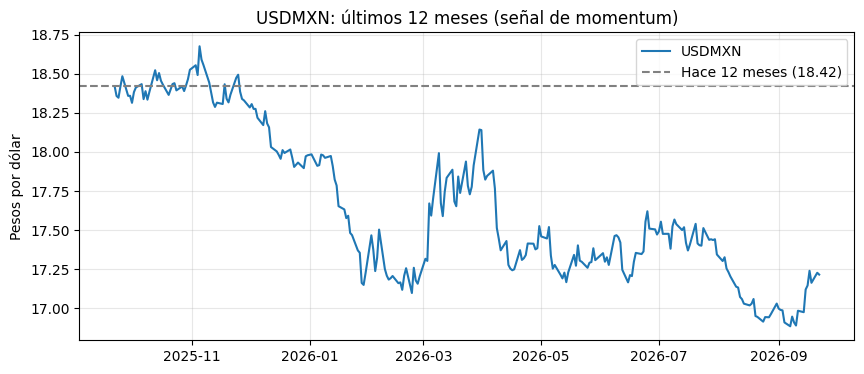

In [8]:
import matplotlib.pyplot as plt

# Gráfica de tendencia 12M 
# Graficamos el USDMXN de los últimos 12 meses porque la señal de
# momentum se entiende mejor visualmente: se ve si el dólar subió
# o bajó frente al peso durante el año.
plt.figure(figsize=(10, 4))
plt.plot(precios_12m.index, precios_12m.values, label="USDMXN")
plt.axhline(P_ini, color="gray", linestyle="--", label=f"Hace 12 meses ({P_ini:.2f})")
plt.title("USDMXN: últimos 12 meses (señal de momentum)")
plt.ylabel("Pesos por dólar")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Conclusión Parte 2 (Momentum)
En los últimos 12 meses el dólar se depreció 6.54% frente al peso; sumando
el carry (−2.6%), su rendimiento total fue de −9.16%. Como el USD tuvo peor
desempeño que el MXN, la regla de momentum del paper indica cubrir.